In [1]:
import numpy as np
from ase import Atoms
from collections import Counter

TYPE_TO_ELEMENT = {13: "Al", 27: "Co", 28: "Ni"}

def parse_fig5(path):
    lines = open(path).read().splitlines()
    text = open(path).read().split()
    cell = np.array([float(x) for x in text[:9]]).reshape(3, 3)
    symbols, scaled = [], []
    for ln in lines:
        parts = ln.split()
        if len(parts) >= 6 and parts[3].isdigit() and parts[4].isdigit():
            x, y, z = float(parts[0]), float(parts[1]), float(parts[2])
            typ = int(parts[3])
            if typ == 0:
                continue
            if typ in TYPE_TO_ELEMENT:
                symbols.append(TYPE_TO_ELEMENT[typ]); scaled.append([x, y, z])
    return Atoms(symbols=symbols, scaled_positions=np.array(scaled), cell=cell, pbc=True)

atoms = parse_fig5("Al9Co2Ni2-coords.txt")
print(len(atoms), "atoms,", dict(Counter(atoms.get_chemical_symbols())))

26 atoms, {'Al': 18, 'Ni': 3, 'Co': 5}


In [2]:
from mace.calculators import mace_mp
from ase.optimize import BFGS
from ase.filters import FrechetCellFilter
import numpy as np

calc = mace_mp(model="medium-mpa-0", device="cpu", default_dtype="float64")
atoms.calc = calc

# TIGHT relaxation - phonons need a much smaller force than the O1 stability check
opt = BFGS(FrechetCellFilter(atoms), logfile=None)
opt.run(fmax=0.001)   # 10x tighter than O1's 0.01

fmax = np.sqrt((atoms.get_forces()**2).sum(axis=1)).max()
print(f"Relaxed. Max residual force: {fmax:.5f} eV/A")
print(f"Energy: {atoms.get_potential_energy():.4f} eV")

/opt/anaconda3/envs/mace-env/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/rameezraja/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/opt/anaconda3/envs/mace-env/lib/python3.11/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Relaxed. Max residual force: 0.00083 eV/A
Energy: -132.7552 eV


In [3]:
import phonopy
from phonopy.structure.atoms import PhonopyAtoms

# convert the relaxed ASE structure into Phonopy's format
ph_atoms = PhonopyAtoms(
    symbols=atoms.get_chemical_symbols(),
    cell=atoms.get_cell().array,
    scaled_positions=atoms.get_scaled_positions(),
)

# create the Phonopy object with a supercell
# start with 2x2x2 - big enough to capture force constants, small enough to be quick
phonon = phonopy.Phonopy(
    ph_atoms,
    supercell_matrix=[[2, 0, 0], [0, 2, 0], [0, 0, 2]],
)

# generate the displaced supercells Phonopy needs
phonon.generate_displacements(distance=0.01)
supercells = phonon.supercells_with_displacements

print(f"Supercell size: {len(phonon.supercell)} atoms")
print(f"Number of displacements to compute: {len(supercells)}")

Supercell size: 208 atoms
Number of displacements to compute: 104


/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_1616/2707116606.py:13: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 0.00000,  0.00000,  1.00000]
  [-0.00000, -1.00000,  0.00000]
  [ 1.00000, -0.00000, -0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonon = phonopy.Phonopy(


In [4]:
import numpy as np
import time

# compute MACE forces on each displaced supercell
force_sets = []
t0 = time.time()
for i, scell in enumerate(supercells):
    a = Atoms(
        symbols=scell.symbols,
        cell=scell.cell,
        scaled_positions=scell.scaled_positions,
        pbc=True,
    )
    a.calc = calc
    force_sets.append(a.get_forces())
    if (i + 1) % 10 == 0:
        elapsed = time.time() - t0
        print(f"  {i+1}/{len(supercells)} done ({elapsed:.0f}s elapsed)")

phonon.forces = force_sets
phonon.produce_force_constants()
print(f"\nForce constants computed in {time.time()-t0:.0f}s total.")

  10/104 done (22s elapsed)
  20/104 done (42s elapsed)
  30/104 done (68s elapsed)
  40/104 done (91s elapsed)
  50/104 done (122s elapsed)
  60/104 done (154s elapsed)
  70/104 done (179s elapsed)
  80/104 done (200s elapsed)
  90/104 done (222s elapsed)
  100/104 done (242s elapsed)

Force constants computed in 251s total.


/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_1616/2337595471.py:8: DeprecationWarning: get_total_dos_dict() is deprecated. Use the total_dos property to access the TotalDos result object; its frequency_points and dos attributes replace the dict keys.
  dos = phonon.get_total_dos_dict()


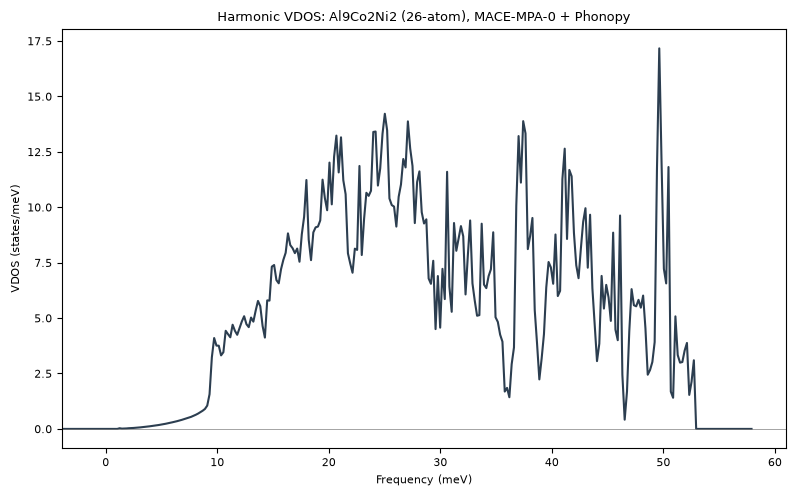

Frequency range: -3.93 to 57.90 meV
Imaginary modes below -0.1 meV: 19 points
  most negative: -3.93 meV


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# compute the phonon density of states on a mesh of q-points
phonon.run_mesh([20, 20, 20])
phonon.run_total_dos(freq_pitch=0.05)

dos = phonon.get_total_dos_dict()
freqs_THz = dos["frequency_points"]
dos_vals = dos["total_dos"]

# convert THz to meV for comparison with the literature (Mihalkovic, Matsuura)
THz_to_meV = 4.13567
freqs_meV = freqs_THz * THz_to_meV

# plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs_meV, dos_vals, color="#2c3e50", lw=1.5)
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("Frequency (meV)")
ax.set_ylabel("VDOS (states/meV)")
ax.set_title("Harmonic VDOS: Al9Co2Ni2 (26-atom), MACE-MPA-0 + Phonopy")
ax.set_xlim(left=min(0, freqs_meV.min()))
plt.tight_layout()
plt.savefig("o2_harmonic_vdos_26atom.png", dpi=150, bbox_inches="tight")
plt.show()

# check the key diagnostics
print(f"Frequency range: {freqs_meV.min():.2f} to {freqs_meV.max():.2f} meV")
neg = freqs_meV[freqs_meV < -0.1]   # imaginary modes show as negative
print(f"Imaginary modes below -0.1 meV: {len(neg)} points")
if len(neg) > 0:
    print(f"  most negative: {freqs_meV.min():.2f} meV")

In [6]:
phonon.save("o2_phonon_26atom.yaml")
print("Saved phonon object")

Saved phonon object


/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_1616/3616267968.py:9: DeprecationWarning: get_projected_dos_dict() is deprecated. Use the projected_dos property to access the ProjectedDos result object; its frequency_points and projected_dos attributes replace the dict keys.
  pdos = phonon.get_projected_dos_dict()


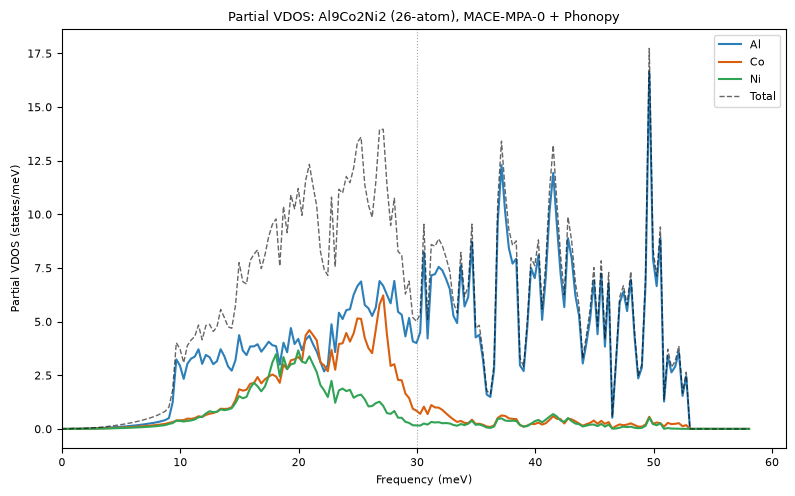

Al: mean freq 32.9 meV, 60% of weight above 30 meV
Co: mean freq 24.2 meV, 13% of weight above 30 meV
Ni: mean freq 22.5 meV, 14% of weight above 30 meV


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# re-run mesh WITH eigenvectors and no symmetry (needed for projected DOS),
# finer mesh for smoothness, tetrahedron method for clean curves
phonon.run_mesh([30, 30, 30], with_eigenvectors=True, is_mesh_symmetry=False)
phonon.run_projected_dos(use_tetrahedron_method=True)

pdos = phonon.get_projected_dos_dict()
freqs_THz = pdos["frequency_points"]
proj = pdos["projected_dos"]          # shape: (n_atoms_in_primitive, n_freq_points)

THz_to_meV = 4.13567
freqs_meV = freqs_THz * THz_to_meV

# group the per-atom projected DOS by element
symbols = phonon.primitive.symbols      # element of each atom in the primitive cell
elements = ["Al", "Co", "Ni"]
colors = {"Al": "#2c7fb8", "Co": "#d95f0e", "Ni": "#31a354"}

element_dos = {}
for el in elements:
    idx = [i for i, s in enumerate(symbols) if s == el]
    if idx:
        element_dos[el] = proj[idx].sum(axis=0)

# plot partial DOS (Al, Co, Ni) plus the total
fig, ax = plt.subplots(figsize=(8, 5))
total = np.zeros_like(freqs_meV)
for el in elements:
    if el in element_dos:
        ax.plot(freqs_meV, element_dos[el], color=colors[el], lw=1.5, label=el)
        total += element_dos[el]
ax.plot(freqs_meV, total, color="black", lw=1.0, ls="--", label="Total", alpha=0.6)

ax.axvline(30, color="gray", lw=0.8, ls=":", alpha=0.7)   # Mihalkovic ~30 meV reference
ax.set_xlabel("Frequency (meV)")
ax.set_ylabel("Partial VDOS (states/meV)")
ax.set_title("Partial VDOS: Al9Co2Ni2 (26-atom), MACE-MPA-0 + Phonopy")
ax.set_xlim(left=0)
ax.legend()
plt.tight_layout()
plt.savefig("o2_partial_vdos_26atom.png", dpi=150, bbox_inches="tight")
plt.show()

# check the literature signature: is Co confined below ~30 meV?
for el in element_dos:
    weighted_mean = np.sum(freqs_meV * element_dos[el]) / np.sum(element_dos[el])
    above_30 = np.sum(element_dos[el][freqs_meV > 30]) / np.sum(element_dos[el]) * 100
    print(f"{el}: mean freq {weighted_mean:.1f} meV, {above_30:.0f}% of weight above 30 meV")

In [8]:
phonon.save("o2_phonon_26atom.yaml")
print("Saved.")

Saved.


In [9]:
import time
import numpy as np

# new Phonopy object at 3x3x3 (uses the SAME tightly-relaxed structure)
phonon33 = phonopy.Phonopy(
    ph_atoms,
    supercell_matrix=[[3, 0, 0], [0, 3, 0], [0, 0, 3]],
)
phonon33.generate_displacements(distance=0.01)
supercells33 = phonon33.supercells_with_displacements

print(f"3x3x3 supercell: {len(phonon33.supercell)} atoms")
print(f"Displacements to compute: {len(supercells33)}")
print("Starting force computation (this is the long part)...\n")

# compute MACE forces on each displaced supercell
force_sets33 = []
t0 = time.time()
for i, scell in enumerate(supercells33):
    a = Atoms(
        symbols=scell.symbols,
        cell=scell.cell,
        scaled_positions=scell.scaled_positions,
        pbc=True,
    )
    a.calc = calc
    force_sets33.append(a.get_forces())
    if (i + 1) % 10 == 0:
        elapsed = time.time() - t0
        rate = elapsed / (i + 1)
        remaining = rate * (len(supercells33) - (i + 1))
        print(f"  {i+1}/{len(supercells33)} done ({elapsed:.0f}s elapsed, ~{remaining:.0f}s left)")

phonon33.forces = force_sets33
phonon33.produce_force_constants()
print(f"\nForce constants computed in {time.time()-t0:.0f}s total.")

/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_1616/1533788007.py:5: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 0.00000,  0.00000,  1.00000]
  [-0.00000, -1.00000,  0.00000]
  [ 1.00000, -0.00000, -0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonon33 = phonopy.Phonopy(


3x3x3 supercell: 702 atoms
Displacements to compute: 104
Starting force computation (this is the long part)...

  10/104 done (183s elapsed, ~1721s left)
  20/104 done (356s elapsed, ~1496s left)
  30/104 done (544s elapsed, ~1342s left)
  40/104 done (722s elapsed, ~1155s left)
  50/104 done (896s elapsed, ~968s left)
  60/104 done (1066s elapsed, ~781s left)
  70/104 done (1265s elapsed, ~614s left)
  80/104 done (1494s elapsed, ~448s left)
  90/104 done (1671s elapsed, ~260s left)
  100/104 done (1847s elapsed, ~74s left)

Force constants computed in 1914s total.


In [10]:
import numpy as np

# compute VDOS for the 3x3x3
phonon33.run_mesh([20, 20, 20])
phonon33.run_total_dos(freq_pitch=0.05)
dos33 = phonon33.get_total_dos_dict()

THz_to_meV = 4.13567
freqs33_meV = dos33["frequency_points"] * THz_to_meV

# imaginary-mode comparison
neg33 = freqs33_meV[freqs33_meV < -0.1]
print("=== IMAGINARY MODE CONVERGENCE CHECK ===\n")
print(f"2x2x2 (208 atoms): 19 imaginary points, most negative -3.93 meV")
print(f"3x3x3 (702 atoms): {len(neg33)} imaginary points, most negative {freqs33_meV.min():.2f} meV")
print()
if freqs33_meV.min() > -3.93:
    print(f"-> Most-negative mode moved from -3.93 toward zero ({freqs33_meV.min():.2f} meV).")
    print("   The imaginary modes shrink with supercell size = finite-size/numerical,")
    print("   not a real instability. This is the expected, benign outcome.")
else:
    print("-> Imaginary modes persist at similar magnitude.")
    print("   This points to a possible real soft mode, worth investigating further.")
print(f"\nFrequency range 3x3x3: {freqs33_meV.min():.2f} to {freqs33_meV.max():.2f} meV")

=== IMAGINARY MODE CONVERGENCE CHECK ===

2x2x2 (208 atoms): 19 imaginary points, most negative -3.93 meV
3x3x3 (702 atoms): 19 imaginary points, most negative -3.96 meV

-> Imaginary modes persist at similar magnitude.
   This points to a possible real soft mode, worth investigating further.

Frequency range 3x3x3: -3.96 to 57.87 meV


/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_1616/969574032.py:6: DeprecationWarning: get_total_dos_dict() is deprecated. Use the total_dos property to access the TotalDos result object; its frequency_points and dos attributes replace the dict keys.
  dos33 = phonon33.get_total_dos_dict()


In [11]:
phonon33.save("o2_phonon_26atom_3x3x3.yaml")
print("Saved 3x3x3 phonon object.")

Saved 3x3x3 phonon object.
